# L1 and L2 Regularization

Regularization helps prevent overfitting by adding a penalty to the cost.

We start from linear regression:

$$
\hat{y} = Xw
$$

and add a penalty term to the objective.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

## 1) Small dataset (with noise)

We create a simple nonlinear target and fit it with polynomial features.
This gives enough flexibility to overfit, so regularization has a clear effect.

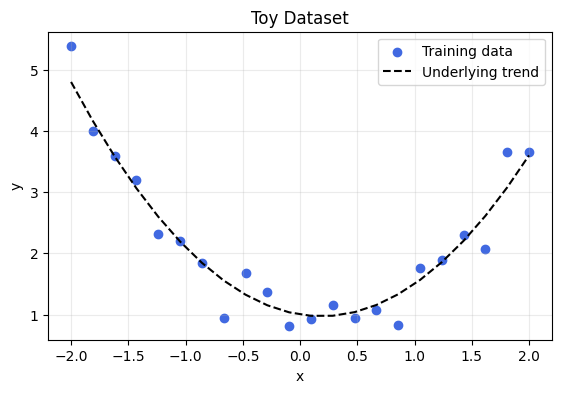

In [2]:
# Training data
x = np.linspace(-2.0, 2.0, 22)
y_true = 0.8 * x**2 - 0.3 * x + 1.0
y = y_true + np.random.normal(0, 0.35, size=x.shape)

plt.figure(figsize=(6.5, 4))
plt.scatter(x, y, color='royalblue', label='Training data')
plt.plot(x, y_true, color='black', linestyle='--', label='Underlying trend')
plt.title('Toy Dataset')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## 2) Cost functions with regularization

Let $m$ be number of examples.

No regularization:

$$
J(w) = \frac{1}{2m}\|Xw-y\|^2
$$

L2 regularization (Ridge):

$$
J_{L2}(w) = \frac{1}{2m}\|Xw-y\|^2 + \frac{\lambda}{2m}\sum_{j=1}^{n} w_j^2
$$

L1 regularization (Lasso):

$$
J_{L1}(w) = \frac{1}{2m}\|Xw-y\|^2 + \frac{\lambda}{m}\sum_{j=1}^{n} |w_j|
$$

- L2 shrinks weights smoothly.
- L1 pushes some weights exactly to zero (feature selection behavior).

In [3]:
def poly_features(x, degree=8):
    cols = [x**d for d in range(1, degree + 1)]
    return np.column_stack(cols)


def standardize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    return (X - mu) / sigma, mu, sigma


X_raw = poly_features(x, degree=8)
X, mu, sigma = standardize(X_raw)

print('Feature matrix shape:', X.shape)

Feature matrix shape: (22, 8)


In [4]:
def fit_gd(X, y, reg=None, lam=0.0, alpha=0.05, iters=6000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0
    history = []

    for _ in range(iters):
        y_hat = X @ w + b
        err = y_hat - y

        dw = (1 / m) * (X.T @ err)
        db = (1 / m) * np.sum(err)

        if reg == 'l2':
            dw += (lam / m) * w
        elif reg == 'l1':
            # subgradient of |w|
            dw += (lam / m) * np.sign(w)

        w -= alpha * dw
        b -= alpha * db

        mse = (1 / (2 * m)) * np.sum(err**2)
        if reg == 'l2':
            mse += (lam / (2 * m)) * np.sum(w**2)
        elif reg == 'l1':
            mse += (lam / m) * np.sum(np.abs(w))
        history.append(mse)

    return w, b, history


def predict(x_vals, w, b, degree=8):
    Xp = poly_features(x_vals, degree=degree)
    Xp = (Xp - mu) / sigma
    return Xp @ w + b

In [5]:
lam = 2.0

w_none, b_none, h_none = fit_gd(X, y, reg=None, lam=0.0)
w_l2, b_l2, h_l2 = fit_gd(X, y, reg='l2', lam=lam)
w_l1, b_l1, h_l1 = fit_gd(X, y, reg='l1', lam=lam)

print('No reg weights (first 5):', np.round(w_none[:5], 3))
print('L2 weights (first 5):    ', np.round(w_l2[:5], 3))
print('L1 weights (first 5):    ', np.round(w_l1[:5], 3))

No reg weights (first 5): [-0.449  0.847  0.186  0.286  0.152]
L2 weights (first 5):     [-0.246  0.606 -0.065  0.324 -0.026]
L1 weights (first 5):     [-0.275  0.796 -0.003  0.246 -0.004]


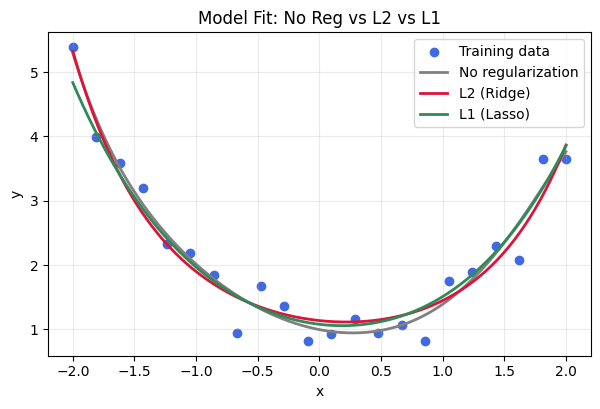

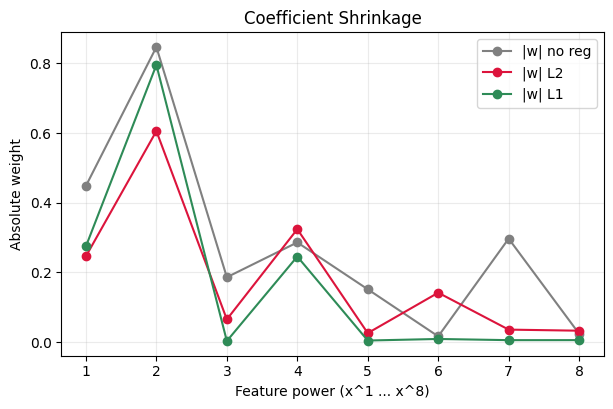

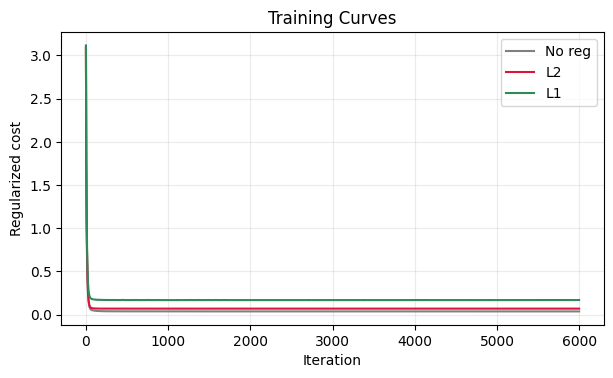

In [6]:
x_line = np.linspace(x.min(), x.max(), 300)

y_none = predict(x_line, w_none, b_none)
y_l2 = predict(x_line, w_l2, b_l2)
y_l1 = predict(x_line, w_l1, b_l1)

plt.figure(figsize=(7, 4.2))
plt.scatter(x, y, color='royalblue', label='Training data')
plt.plot(x_line, y_none, color='gray', linewidth=2, label='No regularization')
plt.plot(x_line, y_l2, color='crimson', linewidth=2, label='L2 (Ridge)')
plt.plot(x_line, y_l1, color='seagreen', linewidth=2, label='L1 (Lasso)')
plt.title('Model Fit: No Reg vs L2 vs L1')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

idx = np.arange(1, len(w_none) + 1)
plt.figure(figsize=(7, 4.2))
plt.plot(idx, np.abs(w_none), 'o-', color='gray', label='|w| no reg')
plt.plot(idx, np.abs(w_l2), 'o-', color='crimson', label='|w| L2')
plt.plot(idx, np.abs(w_l1), 'o-', color='seagreen', label='|w| L1')
plt.xticks(idx)
plt.xlabel('Feature power (x^1 ... x^8)')
plt.ylabel('Absolute weight')
plt.title('Coefficient Shrinkage')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

plt.figure(figsize=(7, 3.8))
plt.plot(h_none, color='gray', label='No reg')
plt.plot(h_l2, color='crimson', label='L2')
plt.plot(h_l1, color='seagreen', label='L1')
plt.xlabel('Iteration')
plt.ylabel('Regularized cost')
plt.title('Training Curves')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

## Quick recap

- Regularization adds a penalty to keep weights small.
- **L2** uses squared weights ($w_j^2$): smooth shrinkage.
- **L1** uses absolute weights ($|w_j|$): can push some weights to zero.
- This often improves generalization when features are many or noisy.

Try changing $\lambda$ (for example: 0.1, 1, 10) and compare the curves and weights.